In [21]:
%pip install pandas numpy matplotlib seaborn scikit-learn xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

In [23]:
df = pd.read_csv('traffic_violations.csv')
print(df.shape, df.columns.tolist())
df.head()

(70340, 21) ['Description', 'Belts', 'Personal.Injury', 'Property.Damage', 'Commercial.License', 'Commercial.Vehicle', 'State', 'VehicleType', 'Year', 'Make', 'Model', 'Color', 'Charge', 'Contributed.To.Accident', 'Race', 'Gender', 'Driver.City', 'Driver.State', 'DL.State', 'Arrest.Type', 'Violation.Type']


,Description,Belts,Personal.Injury,Property.Damage,Commercial.License,Commercial.Vehicle,State,VehicleType,Year,Make,...,Color,Charge,Contributed.To.Accident,Race,Gender,Driver.City,Driver.State,DL.State,Arrest.Type,Violation.Type
0,DISPLAYING EXPIRED REGISTRATION PLATE ISSUED B...,No,No,No,No,No,NC,02 - Automobile,2013.0,HYUNDAI,...,GRAY,13411f,No,WHITE,F,ASHEVILLE,NC,NC,A - Marked Patrol,Citation
1,DRIVER FAIL TO STOP AT RED TRAFFIC SIGNAL BEFO...,No,No,No,No,No,MD,02 - Automobile,2015.0,FORD,...,SILVER,21202i1,No,OTHER,M,SILVER SPRING,MD,MD,A - Marked Patrol,Citation
2,DRIVING UNDER THE INFLUENCE OF ALCOHOL PER SE,No,No,No,No,No,MD,02 - Automobile,2000.0,TOYOTA,...,BLACK,21902a2,No,BLACK,M,SILVER SPRING,MD,MD,B - Unmarked Patrol,Citation
3,PERSON DRIVING MOTOR VEHICLE ON HIGHWAY OR PUB...,No,No,No,No,No,MD,02 - Automobile,2012.0,HOND,...,BLACK,16303c,No,BLACK,M,COLUMBIA,MD,MD,A - Marked Patrol,Citation
4,DISPLAYING EXPIRED REGISTRATION PLATE ISSUED B...,No,No,No,Yes,No,MD,02 - Automobile,2010.0,FORD,...,BLACK,13411f,No,WHITE,M,MOUNT AIRY,MD,MD,A - Marked Patrol,Citation


In [24]:
df = df.drop(columns=['Description','Charge','DL.State','Model'], errors='ignore')
df['Year'] = df['Year'].fillna(df['Year'].median())
for col in df.select_dtypes(include=['object', 'string']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

le = LabelEncoder()
for col in df.select_dtypes(include=['object', 'string']).columns:
    df[col] = le.fit_transform(df[col].astype(str))

# Target: 1 = Citation (violation), 0 = other
df_orig = pd.read_csv('traffic_violations.csv')
df['target'] = (df_orig['Violation.Type'].fillna('') == 'Citation').astype(int)

X = df.drop(columns=['target','Violation.Type'], errors='ignore')
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [25]:
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=2000, solver='liblinear', random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {'Accuracy': accuracy_score(y_test, y_pred), 'F1': f1_score(y_test, y_pred)}
    print(f"\n{name}:\n{classification_report(y_test, y_pred)}")


Random Forest:
              precision    recall  f1-score   support

           0       0.62      0.67      0.65      7578
           1       0.58      0.52      0.55      6490

    accuracy                           0.60     14068
   macro avg       0.60      0.60      0.60     14068
weighted avg       0.60      0.60      0.60     14068


XGBoost:
              precision    recall  f1-score   support

           0       0.62      0.77      0.68      7578
           1       0.62      0.44      0.51      6490

    accuracy                           0.62     14068
   macro avg       0.62      0.60      0.60     14068
weighted avg       0.62      0.62      0.60     14068


Decision Tree:
              precision    recall  f1-score   support

           0       0.61      0.61      0.61      7578
           1       0.54      0.54      0.54      6490

    accuracy                           0.58     14068
   macro avg       0.58      0.58      0.58     14068
weighted avg       0.58      0.5

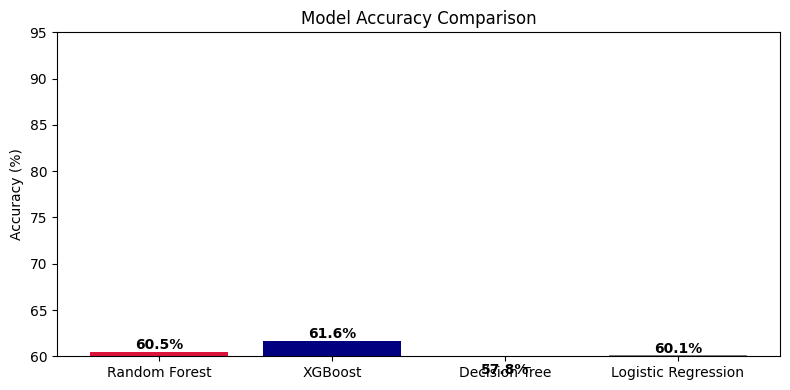

In [26]:
names = list(results.keys())
accs = [results[n]['Accuracy']*100 for n in names]
plt.figure(figsize=(8,4))
bars = plt.bar(names, accs, color=['crimson','navy','steelblue','gray'])
plt.ylim(60, 95)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy (%)')
for b, a in zip(bars, accs):
    plt.text(b.get_x()+b.get_width()/2, a+0.3, f'{a:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

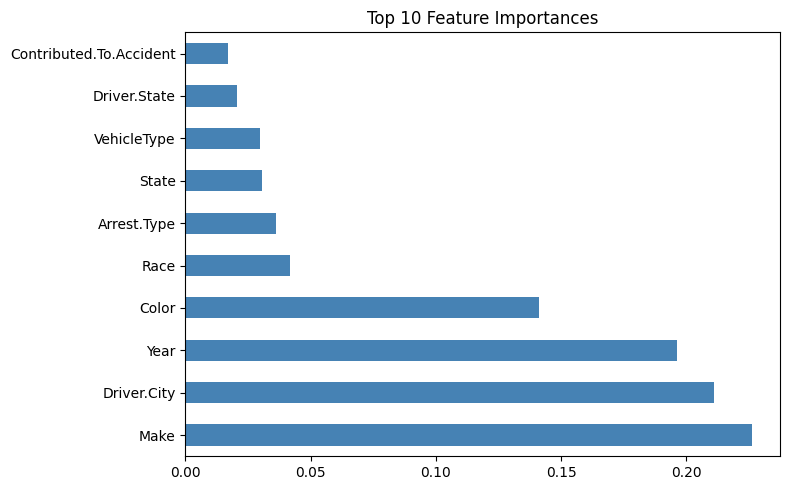

In [27]:
rf = models['Random Forest']
fi = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
fi.plot(kind='barh', figsize=(8,5), color='steelblue', title='Top 10 Feature Importances')
plt.tight_layout(); plt.savefig('feature_importance.png', dpi=150); plt.show()

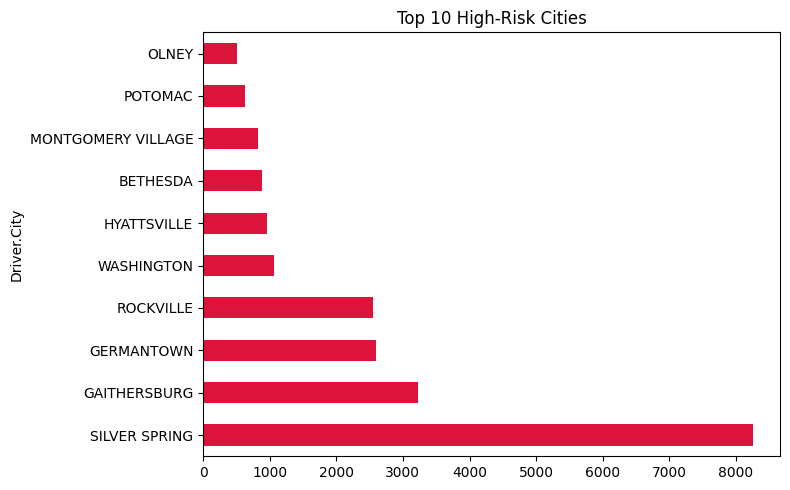

In [28]:
df_orig2 = pd.read_csv('traffic_violations.csv')
df_orig2['is_violation'] = (df_orig2['Violation.Type'] == 'Citation')
risk = df_orig2.groupby('Driver.City')['is_violation'].sum().sort_values(ascending=False).head(10)
risk.plot(kind='barh', figsize=(8,5), color='crimson', title='Top 10 High-Risk Cities')
plt.tight_layout(); plt.savefig('risk_zones.png', dpi=150); plt.show()